In [ ]:
import cv2
import os
data_path="/content/drive/MyDrive/Brain_Tumor"
categories=os.listdir(data_path)
print(categories)

['yes', 'no']


In [ ]:
labels=[i for i in range(len(categories))]
print(labels)

[0, 1]


In [ ]:
label_dict=dict(zip(categories,labels))
print(label_dict)

{'yes': 0, 'no': 1}


In [ ]:
img_size=100                                            # to access the image
data=[]
target=[]

for category in categories:
  folder_path=os.path.join(data_path,category)
  image_names=os.listdir(folder_path)

  for img in image_names:
    img_path=os.path.join(folder_path,img)
    img=cv2.imread(img_path)

    try:                                                 # to resize the image
      gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
      resized=cv2.resize(gray,(img_size,img_size))
      data.append(resized)
      target.append(label_dict[category])

    except Exception as e:
      print("Exception",e)

#This code iterates through each category (e.g., 'yes', 'no') in your categories list. For each category, it goes through all the image files in its corresponding folder. It reads each image using cv2.imread(), converts it to grayscale using cv2.cvtColor(), and then resizes it to a fixed size (img_size x img_size, which is 100x100 pixels in this case). The processed (resized, grayscale) image data is appended to the data list, and its corresponding label (retrieved from label_dict) is appended to the target list. There's also error handling to catch any exceptions that might occur during this process, for example, if an image file is corrupted or unreadable.

In [ ]:
img

In [ ]:
print(len(data))

data[120]

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt    #EDA-->EDA (Exploratory Data Analysis)
plt.figure (figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(data[i])
  plt.axis('off')
plt.show()

In [ ]:
import numpy as np
data = np.array(data)
data.ndim

3

In [ ]:
import numpy as np
data=np.array(data)/255.0
data=np.reshape(data,(data.shape[0],img_size,img_size,1))
target=np.array(target)
data.ndim

4

In [ ]:
from tensorflow.keras.utils import to_categorical
new_target=to_categorical(target)

In [ ]:
new_target[200]

array([0., 1.])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data,new_target,test_size=0.1,random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Flatten,Dropout
from tensorflow.keras.layers import Conv2D,MaxPooling2D      #Import Statements: It imports necessary components from tensorflow.keras, including Sequential for defining the model, and various layers like Dense, Activation, Flatten, Dropout, Conv2D, and MaxPooling2D.

model= Sequential()            #model = Sequential(): This initializes a Sequential model, which is a linear stack of layers.


model.add(Conv2D(200, (3,3),input_shape = data.shape[1:]))                    #This adds the first 2D Convolutional Layer.

     #200: Specifies that this layer will learn 200 different filters (feature detectors).
     #(3,3): Defines the size of each convolutional filter as 3x3 pixels.
     #input_shape = data.shape[1:]: Crucially, this sets the expected input shape for the first layer, which is derived from your data array (excluding the batch size dimension). This tells the model the dimensions of the input images (e.g., 100x100 pixels, 1 channel for grayscale).
model.add(Activation('relu'))                                              #model.add(Activation('relu')): After the convolution, a Rectified Linear Unit (ReLU) activation function is applied. This introduces non-linearity, allowing the network to learn more complex patterns.

model.add(MaxPooling2D(pool_size=(2,2)))                                     #model.add(MaxPooling2D(pool_size=(2,2))): This layer performs max-pooling, which downsamples the feature maps by taking the maximum value over a 2x2 window. This helps reduce the dimensionality, computational cost, and makes the learned features more robust to slight variations in position.


model.add(Conv2D(100, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))                                   #Second Convolutional Block: The next three lines repeat the pattern with Conv2D(100, (3,3)), another Activation('relu'), and MaxPooling2D(pool_size=(2,2)). This creates a second set of convolutional and pooling layers, learning 100 filters, often learning higher-level features.

model.add(Flatten())                                                       #model.add(Flatten()): After the convolutional and pooling layers, the 2D feature maps are flattened into a 1D vector. This is necessary to feed the output into a densely connected (fully connected) neural network layer.
model.add(Dropout(0.5))                                                      #model.add(Dropout(0.5)): This is a regularization technique. During training, it randomly sets 50% of the input units to 0 at each update step. This helps prevent overfitting by making the network less reliant on specific neurons.
model.add(Dense(50,activation='relu'))                                        #model.add(Dense(50,activation='relu')): This adds a densely connected layer with 50 neurons, again using a ReLU activation function. This is a standard hidden layer in a neural network.
model.add(Dense(2,activation='softmax'))                                        #model.add(Dense(2,activation='softmax')): This is the output layer.

    #2: Indicates 2 output neurons, corresponding to your two categories ('yes' and 'no').
    #'softmax': The softmax activation function outputs a probability distribution over the 2 classes, meaning the output values sum to 1, and represent the likelihood of the input image belonging to each class.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 941ms/step - accuracy: 0.6872 - loss: 0.7025 - val_accuracy: 0.5769 - val_loss: 0.5714
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7048 - loss: 0.5811 - val_accuracy: 0.8077 - val_loss: 0.5273
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7885 - loss: 0.5389 - val_accuracy: 0.7692 - val_loss: 0.5012
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
Predicted Category: no
True Category: no
Prediction: Accurate


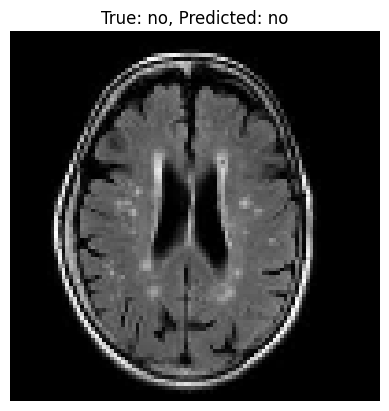

In [ ]:
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3,validation_split=0.2)

# Get one image from the test set
import numpy as np
import matplotlib.pyplot as plt

image_index = 0 # You can change this index to view different images
single_image = x_test[image_index]
true_label = np.argmax(y_test[image_index])

# The model expects a batch of images, so we add a dimension
reshaped_image = np.expand_dims(single_image, axis=0)

# Make a prediction
prediction_probabilities = model.predict(reshaped_image)
predicted_label = np.argmax(prediction_probabilities)

# Map back to category names (assuming 'yes' is 0, 'no' is 1)
reverse_label_dict = {v: k for k, v in label_dict.items()}
predicted_category = reverse_label_dict[predicted_label]
true_category = reverse_label_dict[true_label]

print(f"Predicted Category: {predicted_category}")
print(f"True Category: {true_category}")

if predicted_label == true_label:
    print("Prediction: Accurate")
else:
    print("Prediction: Incorrect")

# Display the image
plt.imshow(single_image.reshape(img_size, img_size), cmap='gray')
plt.title(f"True: {true_category}, Predicted: {predicted_category}")
plt.axis('off')
plt.show()

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7692 - loss: 0.5012
Test Loss: 0.5012
Test Accuracy: 0.7692
